# UE boss damage simulation
This attempts to simulate hitting bosses with certain lt configurations.

For now it supports Overkill, Tanya, The collector, Simba and leopard. 

It doesn't consider lt crits since we don't know the proc chance for that and we assume a baseline of crits dealing double damage without any further investment into crit dmg.

In [268]:
BASE_CRIT_DAMAGE = 100 # this means crit deal double dmg by default

In [269]:
import random
import pandas as pd
from typing import List, Tuple, Dict

def simulate_damage(
    base_damage: float = 10.0,
    percent_damage_mod: float = 0.0,
    percent_boss_damage_mod: float = 0.0,
    crit_chance: float = 25.0,
    crit_damage: float = 50.0,
    num_hits: int = 10000,
    use_ok: bool = False,
    ok_proc_chance: float = 10.0,
    use_collector: bool = True,
    collector_multiplier: float = 3.0,
    use_tanya: bool = False,
    tanya_proc_chance: float = 30,
    tanya_dmg: int = 50,
    use_caio: bool = False,
    caio_proc_chance: float = 15.0,
    use_leopard: bool = False,
    leopard_multiplier: float = 2.0,
    use_simba: bool = False,
    simba_proc_chance: float = 4.0,
    use_silas: bool = False,
    silas_proc_chance: float = 5.0,
) -> Tuple[List[float], List[Dict[str, float]]]:
    """
    Simulate damage for a series of hits, with optional critical hits,
    overkill procs, Tanya procs, collector procs, Caio procs, simba procs and leopard procs.
    """
    hits = []
    proc_data = []

    for _ in range(num_hits):
        if use_silas and (random.random() < silas_proc_chance / 100):
            modified_base_damage = base_damage * 2
        else:
            modified_base_damage = base_damage
            
        # Calculate the regular damage with generic damage and boss damage modifiers
        regular_damage = modified_base_damage * (1 + percent_damage_mod / 100) * (1 + percent_boss_damage_mod / 100)

        is_crit = False
        collector_proc_occurred = False
        tanya_proc_occurred = False
        ok_proc_occurred = False
        ok_proc_depth = 0
        leopard_proc_occured = False
        simba_proc_occured = False

        # Determine if the hit is a critical hit
        if random.random() < crit_chance / 100:
            is_crit = True
            crit_extra_damage = regular_damage * ((crit_damage + BASE_CRIT_DAMAGE) / 100)
            damage = regular_damage + crit_extra_damage
            
            if use_ok:
                # Handle Overkill chain calculation
                multiplier = 1
                while random.random() < ok_proc_chance / 100:
                    ok_proc_occurred = True
                    ok_proc_depth += 1
                    multiplier *= 2
                    if multiplier >= 64:
                        break
                crit_extra_damage *= multiplier
                damage = regular_damage + crit_extra_damage

            if use_tanya:
                if random.random() < tanya_proc_chance / 100:
                    tanya_proc_occurred = True
                    damage *= 1 + tanya_dmg / 100

            # Handle the collector proc (only on crit)
            if use_collector:
                if random.random() < 15 / 100:
                    collector_proc_occurred = True
                    damage *= collector_multiplier
        else:
            damage = regular_damage
            
        if use_caio:
            if random.random() < caio_proc_chance / 100:
                caio_proc_occurred = True
                damage *= 2

        # handle sk procs
        if use_leopard:
            if random.random() < 10 / 100:
                damage *= leopard_multiplier
                leopard_proc_occured = True

        if use_simba:
            if not leopard_proc_occured:
                 if random.random() < simba_proc_chance / 100:
                    damage *= 3
                    simba_proc_occured = True

        hits.append(damage)
        # Build the proc_data dictionary conditionally
        proc_entry = {
            'Damage': damage,
            'IsCrit': is_crit,
        }

        if use_collector:
            proc_entry['CollectorProcOccurred'] = collector_proc_occurred
        
        if use_ok:
            proc_entry['OKProcOccurred'] = ok_proc_occurred
            proc_entry['OKProcDepth'] = ok_proc_depth
        
        if use_tanya:
            proc_entry['TanyaProcOccurred'] = tanya_proc_occurred
            
        if use_caio:
            proc_entry['CaioProcOccurred'] = caio_proc_occurred

        if use_leopard:
            proc_entry['LeopardProcOccurred'] = leopard_proc_occured

        if use_simba:
            proc_entry['SimbaProcOccurred'] = simba_proc_occured

        proc_data.append(proc_entry)

    return hits, proc_data


## Silas update 09/2025

In [270]:
configs_silas = [
    {
        "lts": "J C G Sil T",
        "crit_chance": 54,
        "crit_dmg": 98,
        "dmg": 82.95,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C G Sil OK",
        "crit_chance": 61,
        "crit_dmg": 98,
        "dmg": 82.95,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
    {
        "lts": "J C Sil OK T",
        "crit_chance": 55,
        "crit_dmg": 50,
        "dmg": 67.2,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
    {
        "lts": "J C G Sil Y",
        "crit_chance": 54,
        "crit_dmg": 98,
        "dmg": 132.65,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C T Sil Y",
        "crit_chance": 48,
        "crit_dmg": 40,
        "dmg": 107.45,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C OK Sil Y",
        "crit_chance": 55,
        "crit_dmg": 40,
        "dmg": 107.45,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
]

# THE big simulation

In [271]:
# assuming 80% of all lts owned for the faction count lts
configs = [
    {
        "lts": "J C Y G S",
        "crit_chance": 44,
        "crit_dmg": 219.2,
        "dmg": 107.45,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },
    {
        "lts": "J C Y M S",
        "crit_chance": 49,
        "crit_dmg": 232.8,
        "dmg": 82.25,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },
    {
        "lts": "J C Y T S",
        "crit_chance": 38,
        "crit_dmg": 171.2,
        "dmg": 82.25,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },
    {
        "lts": "J C Y O S",
        "crit_chance": 45,
        "crit_dmg": 171.2,
        "dmg": 82.25,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },
    {
        "lts": "J C G S T",
        "crit_chance": 47,
        "crit_dmg": 179.6,
        "dmg": 67.2,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },  
    {
        "lts": "J C G S O",
        "crit_chance": 54,
        "crit_dmg": 179.6,
        "dmg": 67.2,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "J C M S T",
        "crit_chance": 52,
        "crit_dmg": 181.2,
        "dmg": 51.45,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },  
    {
        "lts": "J C M S O",
        "crit_chance": 59,
        "crit_dmg": 181.2,
        "dmg": 51.45,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "J C T S O",
        "crit_chance": 48,
        "crit_dmg": 131.6,
        "dmg": 51.45,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "J C G T O",
        "crit_chance": 56,
        "crit_dmg": 98,
        "dmg": 67.2,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "J C Y G T",
        "crit_chance": 46,
        "crit_dmg": 88,
        "dmg": 107.45,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },  
    {
        "lts": "J C Y G O",
        "crit_chance": 53,
        "crit_dmg": 88,
        "dmg": 107.45,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },   
    {
        "lts": "S C Y M O",
        "crit_chance": 58,
        "crit_dmg": 232.8,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "S C M T O",
        "crit_chance": 61,
        "crit_dmg": 181.2,
        "dmg": 0,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "S C Y M A",
        "crit_chance": 62,
        "crit_dmg": 254.4,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },  
    {
        "lts": "S C O M A",
        "crit_chance": 72,
        "crit_dmg": 190.8,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": False,
    },  
    {
        "lts": "J C G Y L",
        "crit_chance": 55,
        "crit_dmg": 88,
        "dmg": 132.65,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": False,
    },    
    {
        "lts": "J C G Sil T",
        "crit_chance": 54,
        "crit_dmg": 98,
        "dmg": 82.95,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C G Sil O",
        "crit_chance": 61,
        "crit_dmg": 98,
        "dmg": 82.95,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
    {
        "lts": "J C Sil O T",
        "crit_chance": 55,
        "crit_dmg": 50,
        "dmg": 67.2,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
    {
        "lts": "J C G Sil Y",
        "crit_chance": 54,
        "crit_dmg": 98,
        "dmg": 132.65,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C T Sil Y",
        "crit_chance": 48,
        "crit_dmg": 40,
        "dmg": 107.45,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
        "use_silas": True
    },
    {
        "lts": "J C O Sil Y",
        "crit_chance": 55,
        "crit_dmg": 40,
        "dmg": 107.45,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
        "use_silas": True
    },
]


In [272]:
configs_all_lts_owned = [
    {
        "lts": "J C Y G S",
        "crit_chance": 44,
        "crit_dmg": 251.2,
        "dmg": 134.4,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
    },
    {
        "lts": "J C Y M S",
        "crit_chance": 49,
        "crit_dmg": 272.4,
        "dmg": 102.9,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
    },
    {
        "lts": "J C Y T S",
        "crit_chance": 38,
        "crit_dmg": 203.2,
        "dmg": 102.9,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
    },
    {
        "lts": "J C Y O S",
        "crit_chance": 45,
        "crit_dmg": 203.2,
        "dmg": 102.9,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },
    {
        "lts": "J C G S T",
        "crit_chance": 47,
        "crit_dmg": 199.6,
        "dmg": 83.65,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
    },  
    {
        "lts": "J C G S O",
        "crit_chance": 54,
        "crit_dmg": 199.6,
        "dmg": 83.65,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "J C M S T",
        "crit_chance": 52,
        "crit_dmg": 206,
        "dmg": 64.05,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
    },  
    {
        "lts": "J C M S O",
        "crit_chance": 59,
        "crit_dmg": 206,
        "dmg": 64.05,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "J C T S O",
        "crit_chance": 48,
        "crit_dmg": 151.6,
        "dmg": 64.05,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "J C G T O",
        "crit_chance": 56,
        "crit_dmg": 98,
        "dmg": 83.65,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "J C Y G T",
        "crit_chance": 46,
        "crit_dmg": 88,
        "dmg": 134.4,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
    },  
    {
        "lts": "J C Y G O",
        "crit_chance": 53,
        "crit_dmg": 88,
        "dmg": 134.4,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },   
    {
        "lts": "S C Y M O",
        "crit_chance": 58,
        "crit_dmg": 272.4,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "S C M T O",
        "crit_chance": 61,
        "crit_dmg": 206,
        "dmg": 0,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "S C Y M A",
        "crit_chance": 62,
        "crit_dmg": 301.6,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
    },  
    {
        "lts": "S C O M A",
        "crit_chance": 72,
        "crit_dmg": 220.4,
        "dmg": 0,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": True,
    },  
    {
        "lts": "J C G Y L",
        "crit_chance": 55,
        "crit_dmg": 88,
        "dmg": 165.9,
        "use_tanya": False,
        "use_collector": True,
        "use_overkill": False,
    },   
    {
        "lts": "S C Y M T",
        "crit_chance": 51,
        "crit_dmg": 272.4,
        "dmg": 0,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": False,
    },  
    {
        "lts": "J C Y T O",
        "crit_chance": 47,
        "crit_dmg": 40,
        "dmg": 102.9,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
    }, 
    {
        "lts": "S C Y T O",
        "crit_chance": 47,
        "crit_dmg": 203.2,
        "dmg": 0,
        "use_tanya": True,
        "use_collector": True,
        "use_overkill": True,
    }, 
]

In [273]:
# Example usage
num_hits = 100000
base_damage = 10
ok_proc_chance = 24
collector_multiplier = 3.5  # Multiplier for the entire hit
tanya_dmg = 110
silas_proc_chance = 15

# Initialize a dictionary to store results for all configurations
results = {
    "config": [],
    "hits": [],
    "proc_data": []
}

for config in configs:
# Initialize lists to store results from each run

    print(f"calculating for setup: {config["lts"]}")

    hits, proc_data = simulate_damage(
        base_damage=base_damage, 
        percent_damage_mod=config["dmg"], 
        crit_chance=100,#config["crit_chance"], 
        crit_damage=config["crit_dmg"], 
        num_hits=num_hits, 
        use_ok=config["use_overkill"], 
        use_collector=config["use_collector"],
        ok_proc_chance=ok_proc_chance, 
        collector_multiplier=collector_multiplier,
        use_tanya=config["use_tanya"],
        tanya_dmg=tanya_dmg,
        use_silas=config["use_silas"],
        silas_proc_chance=silas_proc_chance
        )

    # Add each run's data to the results dictionary
    results["config"].append(config)
    results["hits"].append(hits)
    results["proc_data"].append(proc_data)

# Convert results to a DataFrame for easier analysis and plotting
results_df = pd.DataFrame(results)


calculating for setup: J C Y G S
calculating for setup: J C Y M S
calculating for setup: J C Y T S
calculating for setup: J C Y O S
calculating for setup: J C G S T
calculating for setup: J C G S O
calculating for setup: J C M S T
calculating for setup: J C M S O
calculating for setup: J C T S O
calculating for setup: J C G T O
calculating for setup: J C Y G T
calculating for setup: J C Y G O
calculating for setup: S C Y M O
calculating for setup: S C M T O
calculating for setup: S C Y M A
calculating for setup: S C O M A
calculating for setup: J C G Y L
calculating for setup: J C G Sil T
calculating for setup: J C G Sil O
calculating for setup: J C Sil O T
calculating for setup: J C G Sil Y
calculating for setup: J C T Sil Y
calculating for setup: J C O Sil Y


In [274]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average damage and standard deviation for each configuration
results_summary = {
    "lts": [],
    "mean_damage": [],
    "std_dev_damage": []
}

for idx, row in results_df.iterrows():
    mean_damage = pd.Series(row["hits"]).mean()
    std_dev_damage = pd.Series(row["hits"]).std()
    results_summary["lts"].append(row["config"]["lts"])
    results_summary["mean_damage"].append(mean_damage)
    results_summary["std_dev_damage"].append(std_dev_damage)

summary_df = pd.DataFrame(results_summary)

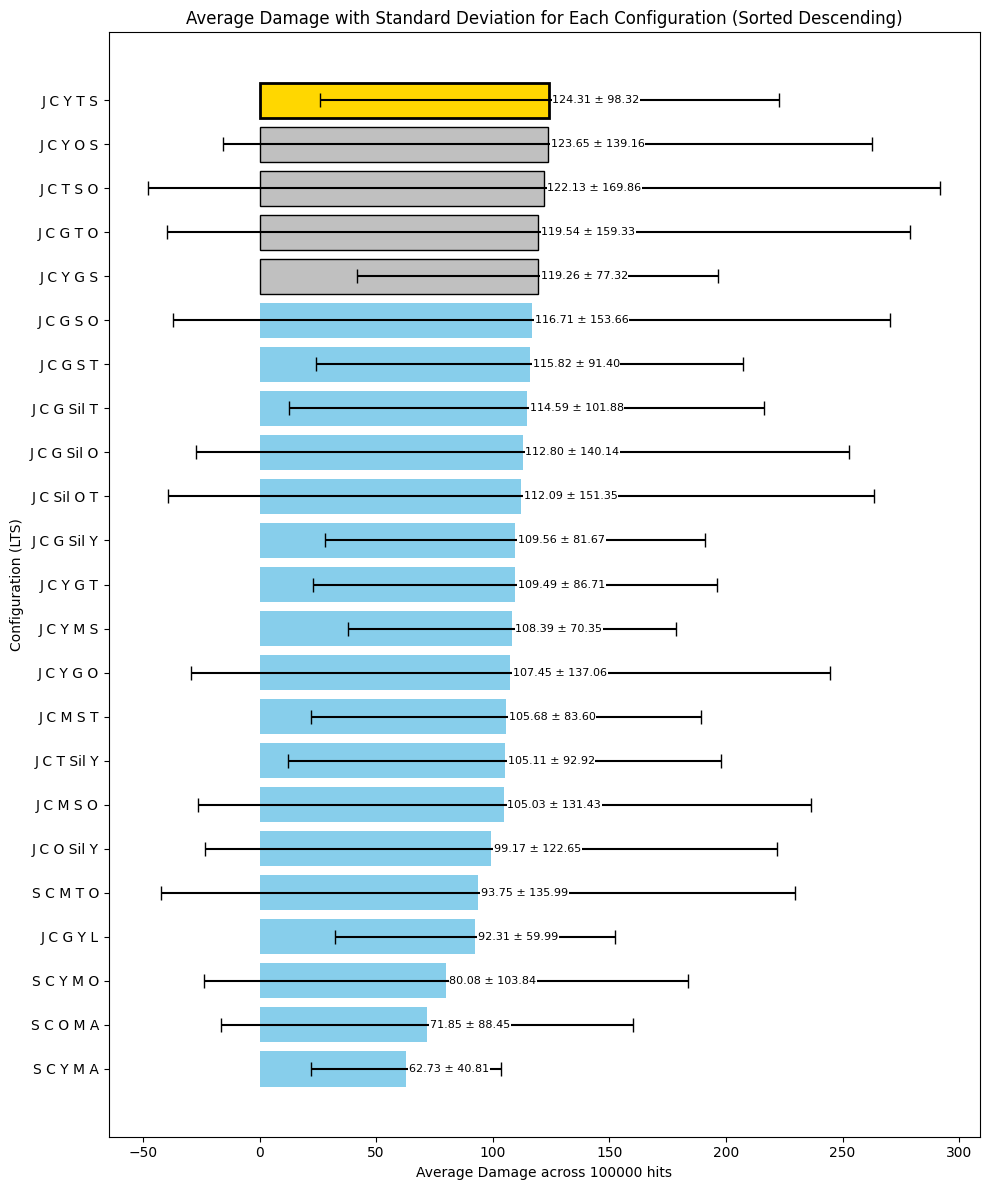

In [275]:
# Sort ascending by mean damage
summary_sorted = summary_df.sort_values("mean_damage", ascending=True).reset_index(drop=True)

# Find top 5 and top 1 based on the *sorted* DataFrame
top5_idx = summary_sorted["mean_damage"].nlargest(5).index
top1_idx = summary_sorted["mean_damage"].idxmax()

plt.figure(figsize=(10, 12))

bars = []
for i, (lts, mean, std) in enumerate(zip(summary_sorted["lts"], summary_sorted["mean_damage"], summary_sorted["std_dev_damage"])):
    if i == top1_idx:  # very top one
        color = "gold"
        edgecolor = "black"
        linewidth = 2
    elif i in top5_idx:  # the other top 5
        color = "silver"
        edgecolor = "black"
        linewidth = 1
    else:  # the rest
        color = "skyblue"
        edgecolor = None
        linewidth = 0
    
    bar = plt.barh(
        lts, mean,
        xerr=std, capsize=5,
        color=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=1   # keep bars behind text
    )
    bars.append(bar)

plt.ylabel("Configuration (LTS)")
plt.xlabel(f"Average Damage across {num_hits} hits")
plt.title("Average Damage with Standard Deviation for Each Configuration (Sorted Descending)")

# Annotate with white-boxed labels
for bar_group, mean, std in zip(bars, summary_sorted["mean_damage"], summary_sorted["std_dev_damage"]):
    bar = bar_group[0]
    plt.text(
        bar.get_width() + (0.01 * summary_sorted["mean_damage"].max()),
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.2f} ± {std:.2f}",
        va='center',
        ha='left',
        fontsize=8,
        zorder=2,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.5, alpha=1)
    )

plt.tight_layout()
plt.show()
